# LFM Semantic Segmentation Example Workflow
This notebook trains a Graha/Lunar-FM semantic segmentation model for crater-vs-background mask prediction. It loads a split semantic segmentation dataset, builds the Graha datamodule and TerraTorch segmentation task, runs fine-tuning, writes checkpoints, and creates validation prediction plots.

## Purpose of this notebook
Use this notebook as the active interactive Graha semantic-segmentation training workflow. The values in the **User Configuration** section mirror the most commonly changed command-line options; lower-level options stay on the centralized experiment-config defaults unless they are explicitly promoted into that section.

**Note**: dataset-specific image/label matching, band selection, normalization modality, and Graha input modality are controlled by `DATA_DICT` in the **User Configuration** section. See the repository README for dataset-specific examples.


## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import sys

from functools import partialmethod
from glob import glob
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
from lightning.pytorch import seed_everything
from tqdm import tqdm

tqdm.__init__ = partialmethod(tqdm.__init__, disable=False)

In [2]:
repo_root = Path.cwd().parent
NOTEBOOK_DIR = repo_root / "notebooks"

if not (repo_root / "lfm").exists():
  raise FileNotFoundError(
      "Cannot find lfm/ directory. Run this notebook from "
      "lfm/notebooks/full_model or update repo_root."
  )

sys.path.insert(0, str(repo_root))

from lfm.all_models.all_tasks.utils import (
    create_timestamped_output_dir,
    save_prediction_cache,
)
from lfm.all_models.sem_seg import build_graha_notebook_configs
from lfm.all_models.sem_seg.plotting import plot_prediction_cache_comparison
from lfm.full_model.sem_seg import semantic_graha_components

print("Successfully imported LFM modules")

/explore/nobackup/projects/lfm/lfm-full-env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Successfully imported LFM modules


## User Configuration

These are the values a notebook user is expected to edit for a normal Graha semantic-segmentation run.

### Paths
`BASE_OUTPUT_DIR`: parent directory for timestamped notebook outputs. Checkpoints, config files, prediction caches, and plots are written under a new timestamped subdirectory.

`PRETRAIN_DIR`: Graha/Lunar-FM pretraining directory. It must contain `checkpoints/checkpoint_weights_final.pt`, `full_config.yaml`, and `modality_info.yaml`.

`LIGHTNING_CHECKPOINT`: optional Graha Lightning checkpoint to resume from. Leave as `None` for a fresh fine-tune.

### Data Selection
To switch datasets, replace `DATA_DICT` with the matching dictionary from the README, under **"Dataset Specifications"**. If you'd like to use your own dataset (not found in the Dataset Specifications section of the README), reference `docs/dataset_contribution.md`.

`DATA_DICT`: dataset-level dictionary that controls the data-specific parts of training. It defines the dataset modality, dataset directory location, chip and label glob patterns, and selected chip bands. Normalization modality and semantic label source are inferred from `dataset_modality` and the label files. 

`DATA_DICT["dataset_name"]`: dataset name for readability. Has no effect on model/dataset functionality. 

`DATA_DICT["data_dir"]`: path to dataset root. This root will have train/val/test folders nested under it.

`DATA_DICT["dataset_modality"]`: modality of the dataset ("wac" or "nac" for currently supported datasets).

`DATA_DICT["image_glob"]/["label_glob"]`: filename pattern to use when finding images/labels in dataset. 

`DATA_DICT["band_filters"]`: modality-local band selection. For WAC, `"vis": [0, 1, 2, 3, 4]` and `"uv": [0, 1]` selects all 7 stored WAC channels. For NAC PHO or DTM, use `[0]` because each modality is stored as a single band. If you would like to remove either "vis" or "uv" modality for WAC, you can delete that entry (so if I wanted only "wac", I would delete the "uv" line entirely).

`MAX_TRAIN_SAMPLES`, `MAX_VAL_SAMPLES`, `MAX_TEST_SAMPLES`: optional split caps for quick experiments. Set any of these to `None` to use the full split. If less samples are found than the max amount, then the actual sample number will be used. 

### Training And Visualization
`BATCH_SIZE`: Graha training batch size. Typically a multiple of 8 to aid parallelization in GPU architecture. 

`MAX_EPOCHS`: number of fine-tuning epochs. The default is currently 1 for demonstration purposes, but to achieve a better science result set this to a higher number, typically 50-100 are used for finetuning.

`GRAHA_BACKBONE_LR`, `GRAHA_HEAD_LR`, `GRAHA_LAYER_DECAY`, `GRAHA_WEIGHT_DECAY`, `GRAHA_WARMUP_STEPS`: Graha optimizer schedule parameters.

`GRAHA_SHAPE_LOSS_WEIGHT`, `GRAHA_SHAPE_LOSS_PAD_FRAC`: Graha semantic shape-loss settings. Set `GRAHA_SHAPE_LOSS_WEIGHT=0.0` to disable shape-loss contribution.


### Defaults Kept In Code
The notebook leaves these centralized defaults unchanged unless you intentionally add overrides to the config cell. File suffixes are inferred automatically from common names such as `_input_nac_chip`, `_input_wac_chip`, `_label`, `_mask`, and `_img`; add explicit `image_suffix` or `label_suffix` only for unusual datasets. Normalization source defaults to `"pretrain"`. A seed of 42 is used for random number generators, to ensure reproducibility. 

In [3]:
BASE_OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "semantic_seg_finetuning"  # Base output directory for finetune plots etc.
PRETRAIN_DIR = "/explore/nobackup/projects/lfm/ibm_model_pretrain_dir"  # Where to load Graha configuration/checkpoint from
LIGHTNING_CHECKPOINT = None  # Fine-tuned checkpoint to resume from (fresh starts should use 'None')

# Data dictionary; see README under "Dataset Specifications" for examples
DATA_DICT = {
    "dataset_name": "nac_imp_old",  # Human-readable dataset name (has no functional effect)
    "data_dir": "/explore/nobackup/projects/lfm/model_inputs/256_256_inputs/imp/old_imp/imp_sem_seg_clean_targets_only",   # Data directory on /explore
    "dataset_modality": "nac",  # Dataset modality
    "image_glob": "*.tif",  # Image (chip) filename pattern the dataset will look for
    "label_glob": "*_label.npz",   # Label (mask) filename pattern the dataset will look for
    "band_filters": {  # Band filters for each modality
        "pho": [0],  # PHO channels to use (0-indexed)
    },
}

# Upper limit for sample counts in train/val/test datasets; if less samples are found, that amount will be used instead
MAX_TRAIN_SAMPLES = 500
MAX_VAL_SAMPLES = 500
MAX_TEST_SAMPLES = 500

BATCH_SIZE = 8  # Number of inputs fed into the model per iteration; often a multiple of 8 for parallelization purposes
MAX_EPOCHS = 1  # Maximum number of epochs, default to 1 for demo purposes. Finetuning typically uses 50-100 epochs, but sometimes less can work.

# General training parameters
GRAHA_BACKBONE_LR = 5.0e-5  # Learning rate for Graha FM backbone (lower than head typically)
GRAHA_HEAD_LR = 2.0e-4  # Learning rate for task decoder (higher than backbone typically)
GRAHA_LAYER_DECAY = 0.75  # Decays learning rate further toward the backbone; allows for more gentle tuning of Graha backbone weights
GRAHA_WEIGHT_DECAY = 0.05  # Penalizes large model weights during training, helping model generalize to non-training data
GRAHA_WARMUP_STEPS = 500  # Number of optimizer steps before LR scheduler warmup ends
GRAHA_FREEZE_BACKBONE = False  # Whether to omit Graha backbone from training (can be a useful tool to switch on/off)

# Semantic segmentation-specific loss parameters
GRAHA_SHAPE_LOSS_WEIGHT = 0.05  # Weighting of "shape loss"; higher numbers penalize non-circular predictions more
GRAHA_SHAPE_LOSS_PAD_FRAC = 0.3  # Fractional padding around target boxes used by shape loss

The configuration cell above mirrors the active Graha semantic-segmentation training settings. Values not listed there use the centralized defaults documented in the previous markdown cell.


In [4]:
OUTPUT_DIR = create_timestamped_output_dir(BASE_OUTPUT_DIR)

notebook_configs = build_graha_notebook_configs(
    output_dir=OUTPUT_DIR,
    base_output_dir=OUTPUT_DIR,
    graha_base_output_dir=OUTPUT_DIR,
    graha_pretrain_dir=PRETRAIN_DIR,
    graha_lightning_checkpoint=LIGHTNING_CHECKPOINT,
    data_dict=DATA_DICT,
    max_epochs=MAX_EPOCHS,
    graha_batch_size=BATCH_SIZE,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_val_samples=MAX_VAL_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
    graha_backbone_lr=GRAHA_BACKBONE_LR,
    graha_head_lr=GRAHA_HEAD_LR,
    graha_layer_decay=GRAHA_LAYER_DECAY,
    graha_weight_decay=GRAHA_WEIGHT_DECAY,
    graha_warmup_steps=GRAHA_WARMUP_STEPS,
    graha_freeze_backbone=GRAHA_FREEZE_BACKBONE,
    graha_shape_loss_weight=GRAHA_SHAPE_LOSS_WEIGHT,
    graha_shape_loss_pad_frac=GRAHA_SHAPE_LOSS_PAD_FRAC
)

config = notebook_configs.experiment_config
graha_config = notebook_configs.graha_config
deps = notebook_configs.dependencies

seed_everything(config.seed)

print("Config created successfully")
print(f"Data dir: {config.data_root}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Graha modality mode: {config.graha_input_modality_mode}")
print(f"Normalization modality: {config.normalization_modality}")
print(f"Graha backbone LR: {config.graha_backbone_lr}")
print(f"Graha head LR: {config.graha_head_lr}")
print(f"Semantic label source: {config.semantic_label_source}")

Using output subdir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05
PROJ_DATA = /explore/nobackup/projects/lfm/lfm-full-env/share/proj
GDAL_DATA = /explore/nobackup/projects/lfm/lfm-full-env/share/gdal


/explore/nobackup/projects/lfm/lfm-full-env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[rank: 0] Seed set to 42


Config created successfully
Data dir: /panfs/ccds02/nobackup/projects/lfm/model_inputs/256_256_inputs/imp/old_imp/imp_sem_seg_clean_targets_only
Output dir: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05
Graha modality mode: single
Normalization modality: nac
Graha backbone LR: 5e-05
Graha head LR: 0.0002
Semantic label source: instance


Set PyTorch device to CUDA (GPU-accelerated) if possible

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Output Directory
The timestamped output directory was created while building the config. It contains checkpoints, prediction caches, and plots for this run.


In [6]:
print(f"Notebook output directory: {OUTPUT_DIR}")

Notebook output directory: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05


## Create Datamodule
1. Select the semantic datamodule class based on `SEMANTIC_LABEL_SOURCE`.
2. Load normalization statistics.
3. Create the datamodule and inspect one training batch.


In [7]:
datamodule_cls = deps[
    "LunarSemanticFromInstanceDatamodule"
    if config.semantic_label_source == "instance"
    else "LunarSemanticMaskSegmentationDatamodule"
]

print("\nSTEP 1: Loading normalization stats...")
print("=" * 60)
means, stds = semantic_graha_components.get_normalization_stats(
    graha_config,
    datamodule_cls,
)
print("Done.")


STEP 1: Loading normalization stats...
TerraMind NAC pretraining modality info: /panfs/ccds02/nobackup/projects/lfm/ibm_model_pretrain_dir/modality_info.yaml
TerraMind NAC pretraining mean: [0.053995178164645]
TerraMind NAC pretraining std: [0.0374660347301751]
Done.


In [8]:
print("\nSTEP 2: Creating datamodule and inspecting one training batch...")
print("=" * 60)

graha_datamodule = semantic_graha_components.create_datamodule(
    graha_config,
    datamodule_cls,
    means,
    stds,
)
graha_sample_batch = semantic_graha_components.inspect_batch(graha_datamodule)

print("Done.")


STEP 2: Creating datamodule and inspecting one training batch...
[train] Limited to 500 samples
[train] Filtered inputs to channels: [0]
[train] Found 500 matched image-label pairs
[train] Dataset configured for 1 channel(s)
[val] Filtered inputs to channels: [0]
[val] Found 490 matched image-label pairs
[val] Dataset configured for 1 channel(s)
batch keys: dict_keys(['image', 'mask', 'filename', 'crater_boxes', 'num_craters'])
image: (8, 1, 256, 256) torch.float32
batch image per-band mean: [-0.7409234642982483]
batch image per-band std: [0.44259151816368103]
mask: (8, 256, 256) torch.int64
mask values: [0, 1]
crater boxes per image: [(0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4)]
Done.


## Create TerraTorch Task

In [9]:
task_cls = semantic_graha_components.make_downstream_shape_segmentation_task_class(
    deps["LunarShapeSegmentationTask"]
)

graha_task = semantic_graha_components.create_task(
    graha_config,
    task_cls,
    graha_sample_batch,
)
semantic_graha_components.inspect_backbone(graha_task)

WAC channels registered for model: 1
Graha input modality mode: single
Backbone modalities: ['wac']
Backbone merge method: None
Freeze backbone: True
LunarBackbone: using modality_info.yaml from '/panfs/ccds02/nobackup/projects/lfm/ibm_model_pretrain_dir/modality_info.yaml' (20 modalities: ['aspect', 'aspect_3m', 'dtm', 'dtm_3m', 'metadata', 'nac', 'slope', 'slope_3m', 'static_maps', 'tok_aspect', 'tok_aspect_3m', 'tok_dtm', 'tok_dtm_3m', 'tok_nac', 'tok_slope', 'tok_slope_3m', 'tok_uv', 'tok_vis', 'uv', 'vis'])
Auto-detected num_register_tokens=0 from checkpoint
Registered new image modality: wac
New modality embeddings (randomly initialized): 3 keys
encoder_embeddings.aspect.mod_emb
encoder_embeddings.aspect.pos_emb
encoder_embeddings.aspect.proj.weight
encoder_embeddings.aspect_3m.mod_emb
encoder_embeddings.aspect_3m.pos_emb
encoder_embeddings.aspect_3m.proj.weight
encoder_embeddings.dtm.mod_emb
encoder_embeddings.dtm.pos_emb
encoder_embeddings.dtm.proj.weight
encoder_embeddings.dtm

## Run Training

In [10]:
trainer = semantic_graha_components.create_trainer(
    graha_config,
    OUTPUT_DIR,
    deps["ValidationPlotCallback"],
    plot_output_dir=OUTPUT_DIR,
    plots_subdir=Path("plots") / "single_model" / "graha_model",
    checkpoint_subdir=Path("checkpoints") / "graha_model",
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
print("\n" + "=" * 60)
print("Starting training.")
print("=" * 60)

ckpt_path = (
    str(graha_config.lightning_checkpoint)
    if graha_config.lightning_checkpoint is not None
    else None
)
trainer.fit(
    graha_task,
    datamodule=graha_datamodule,
    ckpt_path=ckpt_path,
)

print("Finished training.")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting training.
[train] Limited to 500 samples
[train] Filtered inputs to channels: [0]
[train] Found 500 matched image-label pairs
[train] Dataset configured for 1 channel(s)
[val] Filtered inputs to channels: [0]
[val] Found 490 matched image-label pairs
[val] Dataset configured for 1 channel(s)


Loading `train_dataloader` to estimate number of stepping batches.


[LunarDownstreamShapeSegmentationTask] 2 param groups, 15.7M trainable params. layer_decay=0.75 backbone_lr=5e-05 head_lr=0.0002 new_modalities=['wac']
  head_nd                              lr=2.00e-04 wd=0.00e+00 n=3,522
  head_wd                              lr=2.00e-04 wd=5.00e-02 n=15,670,016


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  214 M │ train │     0 │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

...

Saved validation plot to 
/panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_20
26_08_06-time_11_31_05/plots/single_model/graha_model/validation_epoch_001.png

/explore/nobackup/projects/lfm/lfm-full-env/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

[Graha] train epoch 1 finished in 37.0s

`Trainer.fit` stopped: `max_epochs=1` reached.


Finished training.


## Create And Display Validation Visualizations
Using the saved checkpoint, this section inferences/predicts on the reserved validation dataset and displays a visualization for review. 


In [12]:
prediction_cache = save_prediction_cache(
    task=graha_task,
    datamodule=graha_datamodule,
    output_dir=OUTPUT_DIR,
    model_name="graha",
    split=config.prediction_split,
    n_samples=config.plot_n_samples,
)

prediction_plot = plot_prediction_cache_comparison(
    {"graha": prediction_cache},
    OUTPUT_DIR / "plots" / "single_model" / "graha_model",
    n_samples=config.plot_n_samples,
    filename=f"{config.prediction_split}_semantic_predictions.png",
)
print(f"Saved prediction plot: {prediction_plot}")

[train] Limited to 500 samples
[train] Filtered inputs to channels: [0]
[train] Found 500 matched image-label pairs
[train] Dataset configured for 1 channel(s)
[val] Filtered inputs to channels: [0]
[val] Found 490 matched image-label pairs
[val] Dataset configured for 1 channel(s)
Saved 5 prediction cache file(s) to /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05/prediction_cache/graha/val
Saved side-by-side comparison plot to /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05/plots/single_model/graha_model/val_semantic_predictions.png
Saved prediction plot: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/outputs/semantic_seg_finetuning/date_2026_08_06-time_11_31_05/plots/single_model/graha_model/val_semantic_predictions.png


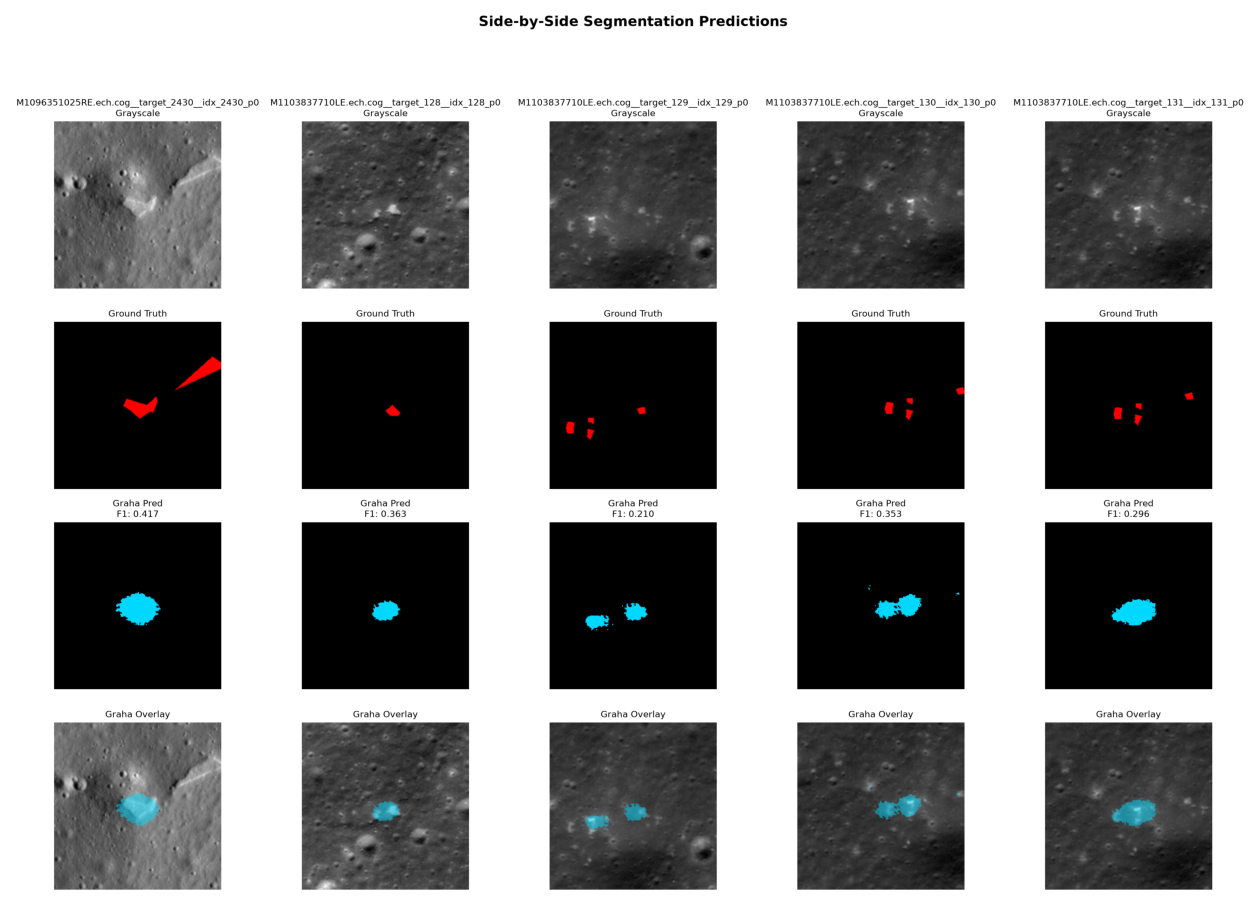

In [13]:
img = mpimg.imread(prediction_plot)
plt.figure(figsize=(16, 14))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
del graha_task, graha_datamodule, trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()